In [1]:
import numpy as np
import pandas
import dpluspy
import moments

In [2]:
import matplotlib, matplotlib.pylab as plt

plt.rcParams["legend.title_fontsize"] = "small"
matplotlib.rc("xtick", labelsize=9)
matplotlib.rc("ytick", labelsize=9)
matplotlib.rc("axes", labelsize=9)
matplotlib.rc("axes", titlesize=9)
matplotlib.rc("legend", fontsize=7)
plt.rcParams['legend.title_fontsize'] = 'small'

In [3]:
# Decode model parameters from model names

T0s = [9e5, 1e6, 1.1e6, 1.3e6, 1.5e6, 1.7e6, 1.9e6, 2.2e6, 2.5e6]
T1s = [1e5, 1.5e5, 2e5, 2.5e5, 3e5, 4e5, 5e5]
ps = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]
HN_pulse = [False, True]
vrs = [HN_pulse, T0s, T1s, ps]
shape = tuple([len(v) for v in vrs])
grid_params = ["MH_pulse", "T_Gho", "T_Gho_Den", "p_Gho_Den"]


def get_grid_params(model):
    idxs = np.unravel_index(model - 1, shape)
    params = {name: [v[i]] for name, v, i in zip(grid_params, vrs, idxs)}
    params["model"] = model
    return params

In [4]:
# Load model 00, 0 results

dfs = []
for ii in range(10):
    dfs.append(pandas.read_csv(f"results/model_00_fit{ii}.csv"))
model_00_df = pandas.concat(dfs)

dfs = []
for ii in range(10):
    dfs.append(pandas.read_csv(f"results/model_0_fit{ii}.csv"))
model_0_df = pandas.concat(dfs)

model_00_best_fit = model_00_df[model_00_df["ll"] == np.max(model_00_df["ll"])]
model_00_best_fit.insert(0, "model", [-1])
model_0_best_fit = model_0_df[model_0_df["ll"] == np.max(model_0_df["ll"])]
model_0_best_fit.insert(0, "model", [0])

dfs = [model_00_best_fit, model_0_best_fit]
dfs

[   model          ll          T_NDH           T_ND         N_Anc  \
 2     -1 -266.904245  801213.511931  558653.851005  15616.942587   
 
           N_Yor          N_ND        N_Den        N_Alt  
 2  29110.385497  11215.954689  3334.276175  3222.839161  ,
    model         ll          T_NDH           T_ND         T_H_N         N_Anc  \
 1      0 -43.315692  765780.008507  712821.117861  302126.21363  16451.195821   
 
          N_Yor         N_ND        N_Den        N_Alt     p_H_N  
 1  27093.95637  1835.494727  4056.826438  2592.234351  0.111507  ]

In [5]:
for model in range(1, 1387):
    if model == 1182:
        best_fit = pandas.DataFrame(get_grid_params(model))
    else:
        df = pandas.read_csv(f"results/grid_model_{model}_fit.csv")
        best_fit = df[df["ll"] == np.max(df["ll"])]
        params = get_grid_params(model)
        best_fit = best_fit.assign(**params)
    dfs.append(best_fit)
df = pandas.concat(dfs)
df.to_csv("grid_fits.csv", index=False)

In [6]:
df

,model,ll,T_NDH,T_ND,N_Anc,N_Yor,N_ND,N_Den,N_Alt,T_H_N,p_H_N,N_Gho,MH_pulse,T_Gho,T_Gho_Den,p_Gho_Den,T_pHN,p_HN
2,-1,-266.904245,801213.511931,558653.851005,15616.942587,29110.385497,11215.954689,3334.276175,3222.839161,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,-43.315692,765780.008507,712821.117861,16451.195821,27093.956370,1835.494727,4056.826438,2592.234351,302126.213630,0.111507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,-273.111891,679685.891350,617776.290267,17467.281963,25555.742560,2819.592513,3319.344711,3518.870046,NaN,NaN,49999.999900,False,900000.0,100000.0,0.005,NaN,NaN
2,2,-258.005960,719393.422742,620202.100874,16854.117095,26781.851941,4429.891710,3040.845348,3529.415789,NaN,NaN,49999.950106,False,900000.0,100000.0,0.010,NaN,NaN
5,3,-255.882497,718533.494803,597949.705730,16847.881215,26782.221886,5347.627402,2358.621605,3426.185486,NaN,NaN,42516.154280,False,900000.0,100000.0,0.020,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,1382,-1209.945869,899999.999996,511212.706107,12935.620252,34996.289986,11949.377970,2913.083298,3253.614673,303865.739947,0.000001,50000.000000,True,2500000.0,500000.0,0.060,NaN,NaN
2,1383,-1786.402396,899999.999998,517612.972031,12653.712262,35554.519981,10932.371266,2907.119804,3344.883730,NaN,NaN,50000.000000,True,2500000.0,500000.0,0.070,302041.283965,0.000001
1,1384,-2486.683114,899999.999995,628391.821095,12349.930495,36164.395026,6664.112083,3078.123436,3961.924866,NaN,NaN,49999.987880,True,2500000.0,500000.0,0.080,305290.645097,0.000001
0,1385,-3309.191094,900000.000000,742650.590259,12002.482839,36716.132088,3215.986463,3117.315752,4403.964352,309442.679452,0.000001,49999.992283,True,2500000.0,500000.0,0.090,NaN,NaN


In [7]:
df0 = df[(df["model"] < 694) & (df["model"] > 0)]
df1 = df[df["model"] >= 694]

<>:25: DeprecationWarning: invalid escape sequence '\D'


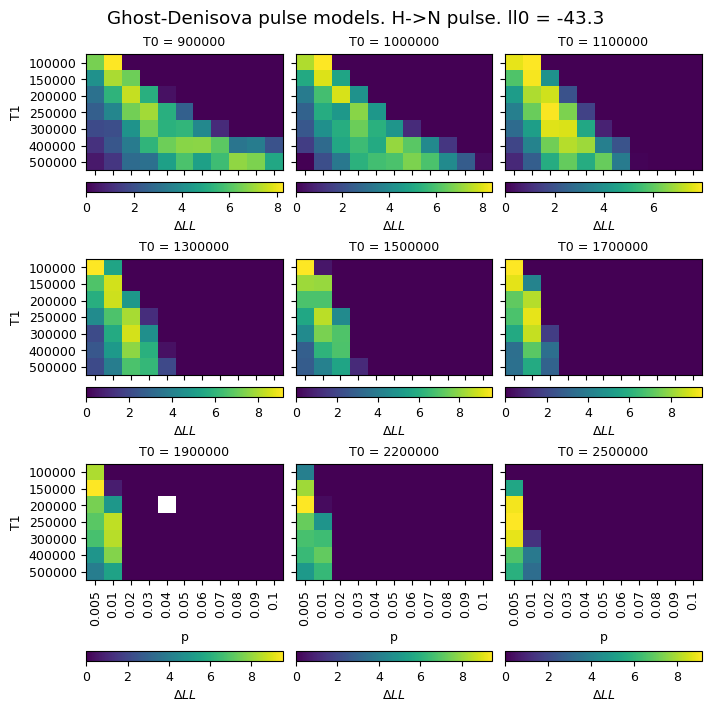

In [8]:
# Plotting likelihoods
plot_df = df1
ll0 = np.array(df[df["model"] == 0]["ll"])[0]

fig, axs = plt.subplots(
    3, 3, figsize=(7, 7), layout="constrained", sharey=True, sharex=True)
axs = axs.flat
fig.suptitle(f"Ghost-Denisova pulse models. H->N pulse. ll0 = {ll0:.3}")

for ii, ax in enumerate(axs):
    T0 = T0s[ii]
    arr = np.zeros((len(T1s), len(ps)))
    for jj, T1 in enumerate(T1s):
        for kk, pp in enumerate(ps):
            ll = np.array(plot_df[
                (plot_df["T_Gho"] == T0)
                & (plot_df["T_Gho_Den"] == T1)
                & (plot_df["p_Gho_Den"] == pp) 
            ]["ll"])[0]
            arr[jj, kk] = ll
    arr = arr - ll0
    arr[arr < 0] = 0
    im = ax.imshow(arr, aspect="auto")
    cbar = ax.figure.colorbar(im, ax=ax, location="bottom")
    cbar.ax.set_xlabel("$\Delta LL$")
    ax.set_xticks(range(arr.shape[1]), labels=ps, rotation=90)
    ax.set_yticks(range(arr.shape[0]), labels=[int(t) for t in T1s])
    ax.set_title(f"T0 = {int(T0)}")
    if ii in (0, 3, 6):
        ax.set_ylabel("T1")
    if ii in (6, 7, 8):
        ax.set_xlabel("p")

plt.savefig("figures/model_1_ll_summary.pdf")

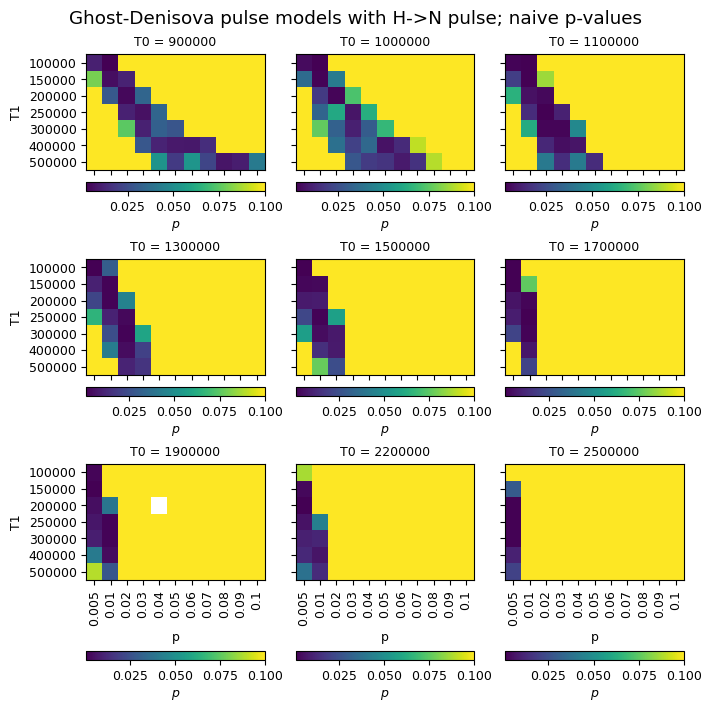

In [9]:
# Plot p-values for model 0
weights = (0, 0, 0, 0, 1)
plot_df = df1
ll0 = np.array(df[df["model"] == 0]["ll"])[0]

fig, axs = plt.subplots(
    3, 3, figsize=(7, 7), layout="constrained", sharey=True, sharex=True)
axs = axs.flat
fig.suptitle(f"Ghost-Denisova pulse models with H->N pulse; naive p-values")

for ii, ax in enumerate(axs):
    T0 = T0s[ii]
    pvals = np.zeros((len(T1s), len(ps)))
    for jj, T1 in enumerate(T1s):
        for kk, pp in enumerate(ps):
            ll = np.array(plot_df[
                (plot_df["T_Gho"] == T0)
                & (plot_df["T_Gho_Den"] == T1)
                & (plot_df["p_Gho_Den"] == pp) 
            ]["ll"])[0]
            D = 2 * (ll - ll0)
            pvals[jj, kk] = moments.Godambe.sum_chi2_ppf(D, weights)
    pvals[pvals > 0.10] = 0.1
    im = ax.imshow(pvals, aspect="auto")
    cbar = ax.figure.colorbar(im, ax=ax, location="bottom")
    cbar.ax.set_xlabel("$p$")
    ax.set_xticks(range(pvals.shape[1]), labels=ps, rotation=90)
    ax.set_yticks(range(pvals.shape[0]), labels=[int(t) for t in T1s])
    ax.set_title(f"T0 = {int(T0)}")
    if ii in (0, 3, 6):
        ax.set_ylabel("T1")
    if ii in (6, 7, 8):
        ax.set_xlabel("p")

plt.savefig("figures/model_1_pval_summary.pdf")

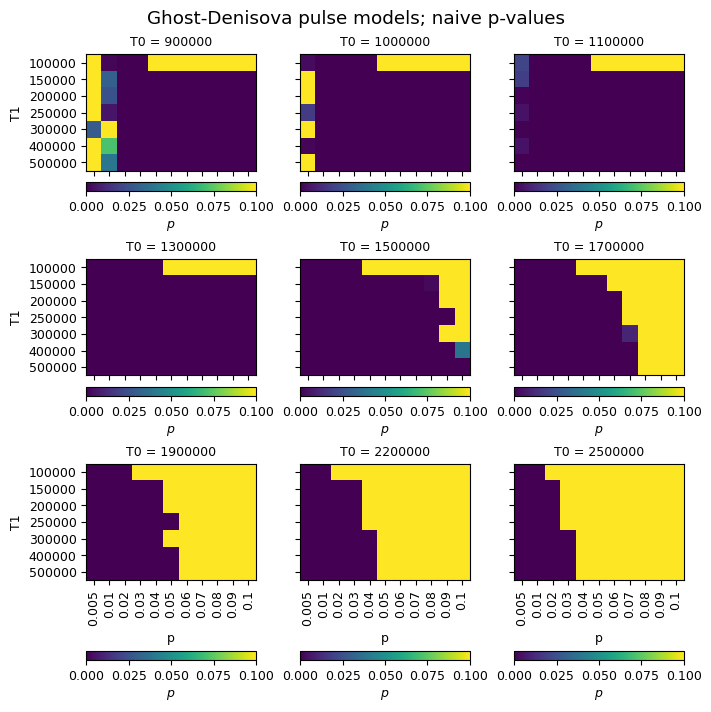

In [10]:
# Plot p-values for model -1
weights = (0, 0, 0, 0, 1)
plot_df = df0
ll0 = np.array(df[df["model"] == -1]["ll"])[0]

fig, axs = plt.subplots(
    3, 3, figsize=(7, 7), layout="constrained", sharey=True, sharex=True)
axs = axs.flat
fig.suptitle(f"Ghost-Denisova pulse models; naive p-values")

for ii, ax in enumerate(axs):
    T0 = T0s[ii]
    pvals = np.zeros((len(T1s), len(ps)))
    for jj, T1 in enumerate(T1s):
        for kk, pp in enumerate(ps):
            ll = np.array(plot_df[
                (plot_df["T_Gho"] == T0)
                & (plot_df["T_Gho_Den"] == T1)
                & (plot_df["p_Gho_Den"] == pp) 
            ]["ll"])[0]
            D = 2 * (ll - ll0)
            pvals[jj, kk] = moments.Godambe.sum_chi2_ppf(D, weights)
    pvals[pvals > 0.10] = 0.10
    im = ax.imshow(pvals, aspect="auto")
    cbar = ax.figure.colorbar(im, ax=ax, location="bottom")
    cbar.ax.set_xlabel("$p$")
    ax.set_xticks(range(pvals.shape[1]), labels=ps, rotation=90)
    ax.set_yticks(range(pvals.shape[0]), labels=[int(t) for t in T1s])
    ax.set_title(f"T0 = {int(T0)}")
    if ii in (0, 3, 6):
        ax.set_ylabel("T1")
    if ii in (6, 7, 8):
        ax.set_xlabel("p")

plt.savefig("figures/model_0_pval_summary.pdf")

<>:25: DeprecationWarning: invalid escape sequence '\D'


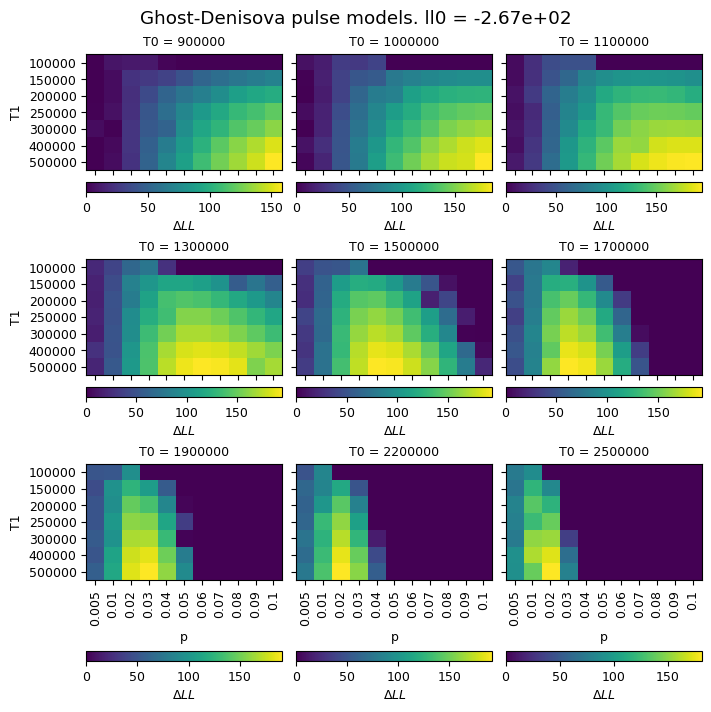

In [11]:
# Plotting likelihoods
plot_df = df0
ll0 = np.array(df[df["model"] == -1]["ll"])[0]

fig, axs = plt.subplots(
    3, 3, figsize=(7, 7), layout="constrained", sharey=True, sharex=True)
axs = axs.flat
fig.suptitle(f"Ghost-Denisova pulse models. ll0 = {ll0:.3}")

for ii, ax in enumerate(axs):
    T0 = T0s[ii]
    arr = np.zeros((len(T1s), len(ps)))
    for jj, T1 in enumerate(T1s):
        for kk, pp in enumerate(ps):
            ll = np.array(plot_df[
                (plot_df["T_Gho"] == T0)
                & (plot_df["T_Gho_Den"] == T1)
                & (plot_df["p_Gho_Den"] == pp) 
            ]["ll"])[0]
            arr[jj, kk] = ll
    arr = arr - ll0
    arr[arr < 0] = 0
    im = ax.imshow(arr, aspect="auto")
    cbar = ax.figure.colorbar(im, ax=ax, location="bottom")
    cbar.ax.set_xlabel("$\Delta LL$")
    ax.set_xticks(range(arr.shape[1]), labels=ps, rotation=90)
    ax.set_yticks(range(arr.shape[0]), labels=[int(t) for t in T1s])
    ax.set_title(f"T0 = {int(T0)}")
    if ii in (0, 3, 6):
        ax.set_ylabel("T1")
    if ii in (6, 7, 8):
        ax.set_xlabel("p")

plt.savefig("figures/model_0_ll_summary.pdf")

In [12]:
print(df1[df1["ll"] == np.max(df1["ll"])])

   model         ll         T_NDH          T_ND         N_Anc         N_Yor  \
2   1002 -33.720077  775626.70901  729549.42248  16238.283706  27555.867939   

          N_ND        N_Den        N_Alt          T_H_N     p_H_N  \
2  1603.711475  3530.241033  2401.203632  249760.301554  0.086978   

         N_Gho MH_pulse      T_Gho  T_Gho_Den  p_Gho_Den  T_pHN  p_HN  
2  7616.491866     True  1500000.0   100000.0      0.005    NaN   NaN  


In [13]:
u = 1.3e-8

graph_0 = "results/model_0_fit4.yaml"
graph_1 = "results/grid_model_1002_fit.yaml"
fdata_Bherer = "../../analyses/recombination_maps/stats/subset_Bherer.pkl"


data = dpluspy.inference.load_stats(
    fdata_Bherer, graph=graph_1, return_dict=True)


model_0 = dpluspy.inference.compute_bin_stats(graph_0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model_1 = dpluspy.inference.compute_bin_stats(graph_1, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)

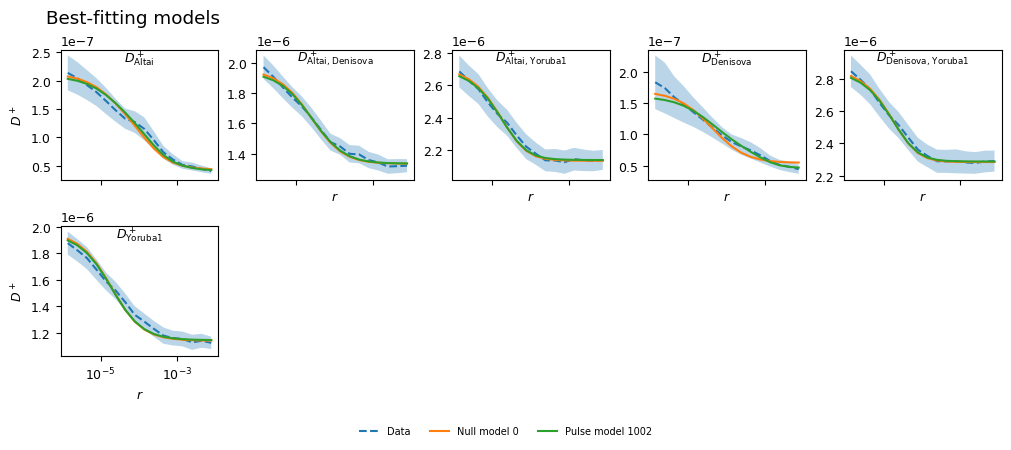

In [14]:
dpluspy.plotting.plot_D_plus_curves(
    models=[model_0, model_1],
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    labels=["Data", "Null model 0", "Pulse model 1002"],
    title="Best-fitting models",
    out="figures/best_fit_model_1002.pdf"
)

In [ ]:
u = 1.3e-8

graph_0 = "results/model_00_fit0.yaml"
graph_1 = "results/grid_model_304_fit.yaml"
fdata_Bherer = "../../analyses/recombination_maps/stats/subset_Bherer.pkl"
data = dpluspy.inference.load_stats(
    fdata_Bherer, graph=graph_1, return_dict=True)
model_0 = dpluspy.inference.compute_bin_stats(graph_0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model_1 = dpluspy.inference.compute_bin_stats(graph_1, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)

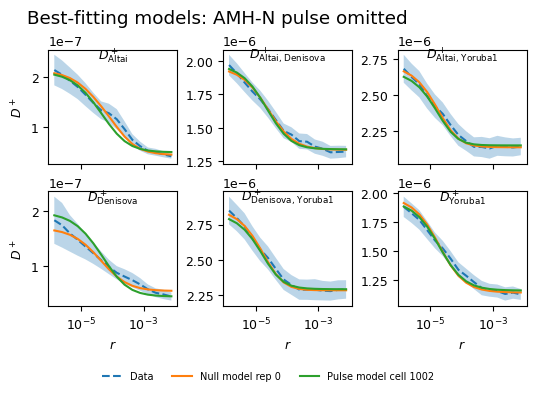

In [20]:
dpluspy.plotting.plot_D_plus_curves(
    models=[model_0, model_1],
    pop_ids=data["pop_ids"], 
    bins=data["bins"], 
    means=data["means"], 
    varcovs=data["varcovs"], 
    labels=["Data", "Null model rep 0", "Pulse model cell 1002"],
    title="Best-fitting models: AMH-N pulse omitted",
    out="figures/model_00_best_fits.png",
    cols=3,
    ax_size=1.75
)